# Introduction to Matplotlib
## A Hands-On Tutorial for Movement Neuroscience Graduate Students

---

**Why this tutorial?**  
Visualization is at the heart of movement neuroscience. Whether you're inspecting raw EMG traces, comparing reaction-time distributions across conditions, plotting joint angle trajectories, or building publication-quality multi-panel figures, Matplotlib is the library that makes it happen. It's the most widely used plotting library in Python, and virtually every other visualization tool (Seaborn, Pandas `.plot()`, MNE-Python's figures) is built on top of it.

This notebook walks you through every essential plot type and customization technique, building from simple one-liners to professional multi-panel figures.

**Prerequisites:** Python Basics (L0), Introduction to NumPy (L1).  
**Environment:** Google Colab (recommended) or Jupyter Notebook.

---

## Table of Contents

**Part I — Basic Plot Types**
1. [Line Plot](#1)
2. [Bar Chart](#2)
3. [Histogram](#3)
4. [Scatter Plot](#4)
5. [Pie Chart](#5)
6. [Box Plot](#6)
7. [Heatmap](#7)

**Part II — Customization**
8. [Customizing Line Charts](#8)
9. [Customizing Bar Charts](#9)
10. [Customizing Histograms](#10)
11. [Customizing Scatter Plots](#11)
12. [Customizing Pie Charts](#12)

**Part III — Figures, Axes, and Subplots**
13. [Figures and Axes — Matplotlib's Core Components](#13)
14. [Creating Subplots — `add_axes`, `subplot`, `subplots`](#14)
15. [Multi-Panel Figures and Saving](#15)

**Part IV — Practice**
16. [Exercises](#16)
17. [Summary & Further Reading](#17)

In [2]:
# ---- Setup: import the two libraries we'll use throughout ----

import numpy as np
import matplotlib.pyplot as plt

---
# Part I — Basic Plot Types

## 1. Line Plot <a id='1'></a>

The **line plot** is the most fundamental plot type. It connects data points with a line, showing how one variable changes with respect to another. Created with `plt.plot()`.

**Neuroscience use:** Plotting time-series signals (EMG, force, joint angles), tracking learning curves across trials.

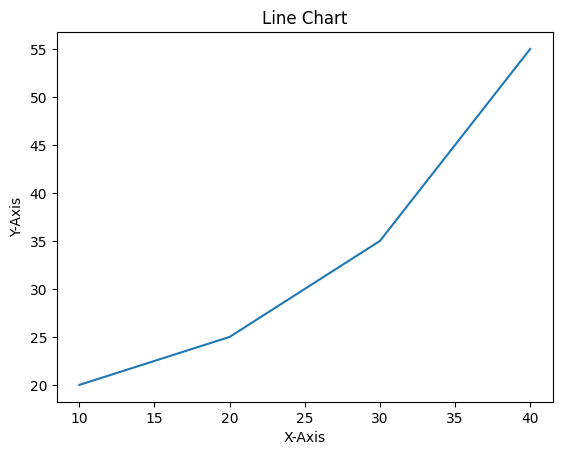

In [3]:
# ---- Basic line plot ----

x = [10, 20, 30, 40]
y = [20, 25, 35, 55]

plt.plot(x, y)                # Plot y vs x as a line
plt.title("Line Chart")       # Title above the plot
plt.xlabel('X-Axis')          # Label for the horizontal axis
plt.ylabel('Y-Axis')          # Label for the vertical axis
plt.show()                    # Display the figure

---
## 2. Bar Chart <a id='2'></a>

**Bar charts** display categorical data using rectangular bars whose lengths are proportional to the values they represent. Created with `plt.bar()`.

**Neuroscience use:** Comparing mean reaction times or error rates across experimental conditions.

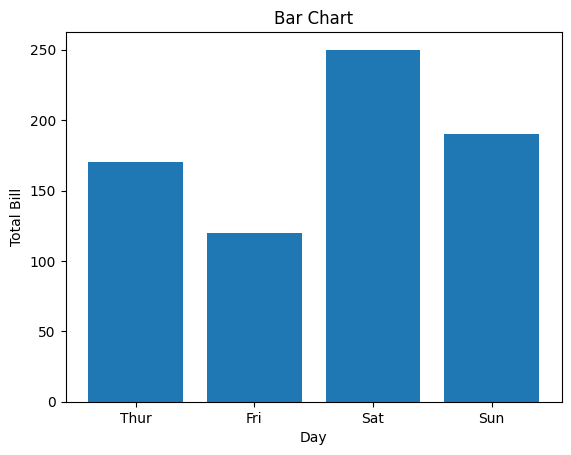

In [4]:
# ---- Basic bar chart ----

x = ['Thur', 'Fri', 'Sat', 'Sun']
y = [170, 120, 250, 190]

plt.bar(x, y)                 # Vertical bars
plt.title("Bar Chart")
plt.xlabel("Day")
plt.ylabel("Total Bill")
plt.show()

---
## 3. Histogram <a id='3'></a>

A **histogram** shows the **distribution** of data by grouping values into bins. The x-axis shows bin ranges, the y-axis shows frequencies. Created with `plt.hist()`.

**Neuroscience use:** Visualizing the distribution of reaction times, movement durations, or endpoint errors across trials.

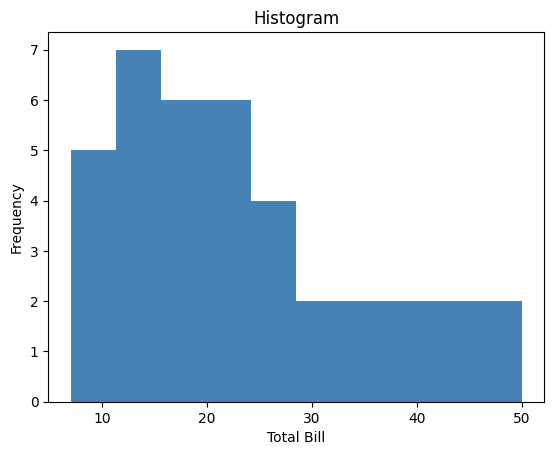

In [5]:
# ---- Basic histogram ----

x = [7, 8, 9, 10, 10, 12, 12, 12, 13, 14, 14, 15, 16, 16, 17,
     18, 18, 19, 20, 20, 21, 22, 23, 24, 25, 25, 26, 28, 30,
     32, 35, 36, 38, 40, 42, 44, 48, 50]

plt.hist(x, bins=10, color='steelblue')  # bins controls how many groups
plt.title("Histogram")
plt.xlabel("Total Bill")
plt.ylabel("Frequency")
plt.show()

---
## 4. Scatter Plot <a id='4'></a>

**Scatter plots** display individual data points to reveal **relationships between two variables**. Created with `plt.scatter()`.

**Neuroscience use:** Plotting peak velocity vs. movement amplitude, EMG onset vs. reaction time, or any two continuous measures against each other.

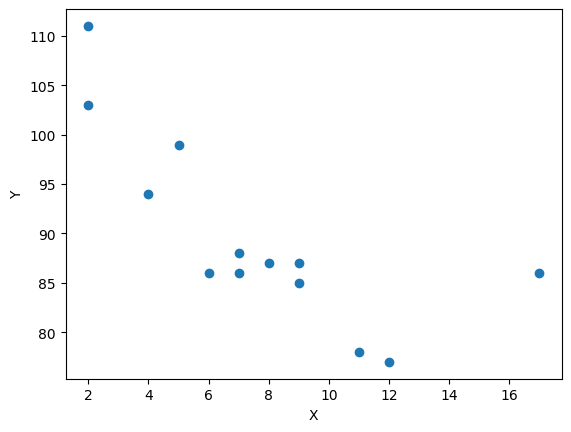

In [6]:
# ---- Basic scatter plot ----

x = [5, 7, 8, 7, 2, 17, 2, 9, 4, 11, 12, 9, 6]
y = [99, 86, 87, 88, 111, 86, 103, 87, 94, 78, 77, 85, 86]

plt.scatter(x, y)
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

---
## 5. Pie Chart <a id='5'></a>

**Pie charts** show data as proportions of a whole. Each slice represents a category's share. Created with `plt.pie()`.

**Neuroscience use:** Showing the proportion of trial outcomes (e.g., hits, misses, false alarms) or time spent in different movement phases.

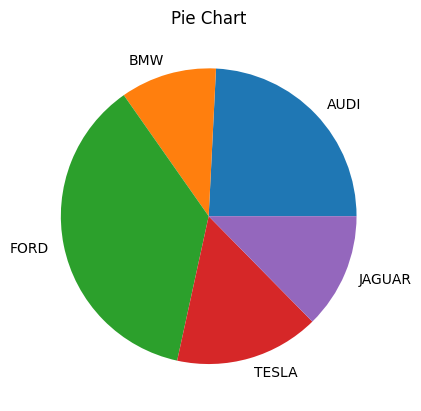

In [7]:
# ---- Basic pie chart ----

cars = ['AUDI', 'BMW', 'FORD', 'TESLA', 'JAGUAR']
data = [23, 10, 35, 15, 12]

plt.pie(data, labels=cars)
plt.title("Pie Chart")
plt.show()

---
## 6. Box Plot <a id='6'></a>

**Box plots** show how data is spread out by displaying the minimum, maximum, median, and quartiles. They're excellent for spotting **outliers**. Created with `plt.boxplot()`.

**Neuroscience use:** Comparing the spread of reaction times or endpoint errors across groups or conditions.

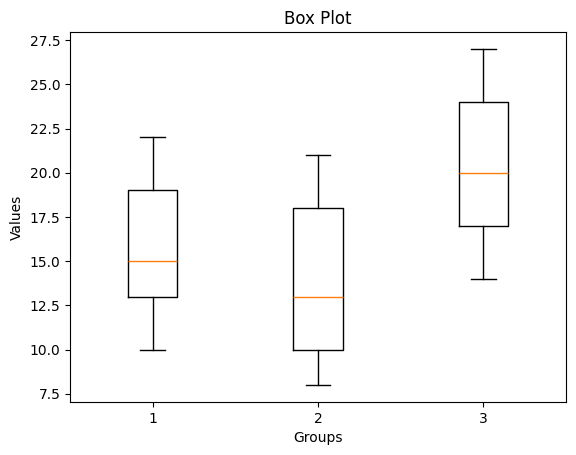

In [8]:
# ---- Basic box plot ----
# Each inner list is a separate group.

data = [[10, 12, 14, 15, 18, 20, 22],
        [8, 9, 11, 13, 17, 19, 21],
        [14, 16, 18, 20, 23, 25, 27]]

plt.boxplot(data)
plt.xlabel("Groups")
plt.ylabel("Values")
plt.title("Box Plot")
plt.show()

---
## 7. Heatmap <a id='7'></a>

**Heatmaps** represent data values as colors in a matrix. They help visualize patterns, correlations, or intensity. Created with `plt.imshow()`.

**Neuroscience use:** Visualizing correlation matrices between muscles, time-frequency spectrograms of neural signals, or muscle synergy patterns.

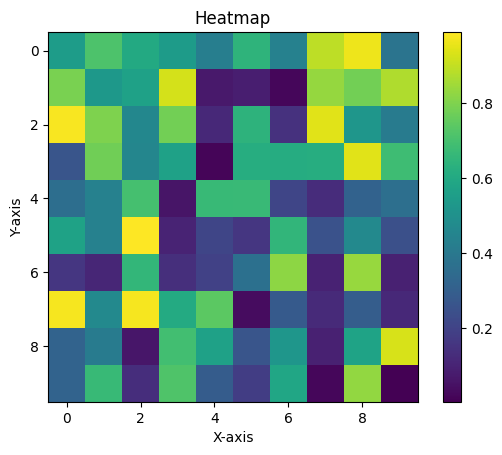

In [9]:
# ---- Basic heatmap ----

np.random.seed(0)
data = np.random.rand(10, 10)  # 10×10 matrix of random values

plt.imshow(data, cmap='viridis', interpolation='nearest')  # cmap = colormap
plt.colorbar()                 # Add a color scale bar on the side
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Heatmap')
plt.show()

---
# Part II — Customization

The basic plots above are functional but plain. In this section, you'll learn how to customize each plot type for presentations and publications.

## 8. Customizing Line Charts <a id='8'></a>

Key customization properties for `plt.plot()`:

| Property | Description | Example values |
|---|---|---|
| `color` | Line color | `'green'`, `'#FF5733'`, `'tab:blue'` |
| `linewidth` | Line thickness | `1`, `2`, `3` |
| `linestyle` | Line pattern | `'-'` (solid), `'--'` (dashed), `':'` (dotted) |
| `marker` | Data point symbol | `'o'` (circle), `'s'` (square), `'^'` (triangle) |
| `markersize` | Size of markers | `5`, `10`, `15` |

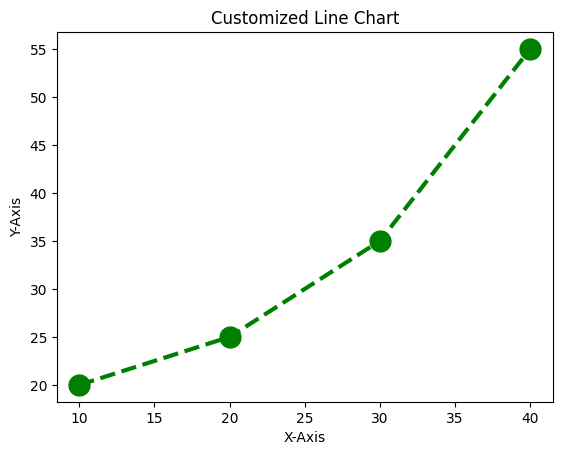

In [10]:
# ---- Customized line chart ----

x = [10, 20, 30, 40]
y = [20, 25, 35, 55]

plt.plot(x, y,
         color='green',       # Line color
         linewidth=3,         # Line thickness
         marker='o',          # Circle markers at each data point
         markersize=15,       # Marker size
         linestyle='--')      # Dashed line

plt.title("Customized Line Chart")
plt.xlabel('X-Axis')
plt.ylabel('Y-Axis')
plt.show()

---
## 9. Customizing Bar Charts <a id='9'></a>

Key customization properties for `plt.bar()`:

| Property | Description |
|---|---|
| `color` | Fill color of the bars |
| `edgecolor` | Color of bar edges |
| `linewidth` | Thickness of edges |
| `width` | Width of each bar (default 0.8) |

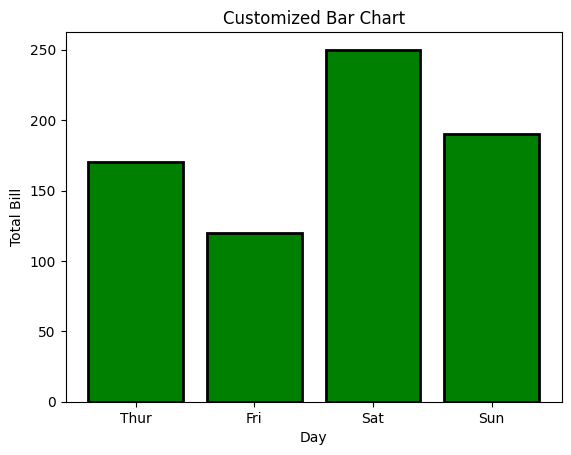

In [11]:
# ---- Customized bar chart ----

x = ['Thur', 'Fri', 'Sat', 'Sun']
y = [170, 120, 250, 190]

plt.bar(x, y,
        color='green',        # Fill color
        edgecolor='black',    # Edge color
        linewidth=2)          # Edge thickness

plt.title("Customized Bar Chart")
plt.xlabel("Day")
plt.ylabel("Total Bill")
plt.show()

---
## 10. Customizing Histograms <a id='10'></a>

Key customization properties for `plt.hist()`:

| Property | Description |
|---|---|
| `bins` | Number of groups to divide data into |
| `color` | Bar fill color |
| `edgecolor` | Bar edge color |
| `linestyle` | Edge line style (`'-'`, `'--'`, `':'`) |
| `alpha` | Transparency (0 = invisible, 1 = opaque) |

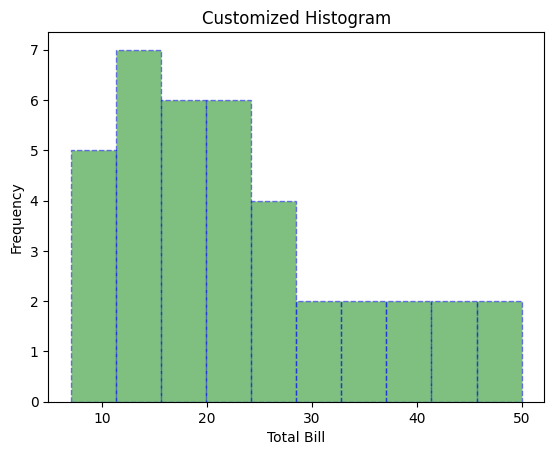

In [12]:
# ---- Customized histogram ----

x = [7, 8, 9, 10, 10, 12, 12, 12, 13, 14, 14, 15, 16, 16, 17,
     18, 18, 19, 20, 20, 21, 22, 23, 24, 25, 25, 26, 28, 30,
     32, 35, 36, 38, 40, 42, 44, 48, 50]

plt.hist(x,
         bins=10,
         color='green',
         edgecolor='blue',
         linestyle='--',
         alpha=0.5)           # 50% transparent

plt.title("Customized Histogram")
plt.xlabel("Total Bill")
plt.ylabel("Frequency")
plt.show()

---
## 11. Customizing Scatter Plots <a id='11'></a>

Key customization properties for `plt.scatter()`:

| Property | Description |
|---|---|
| `s` | Marker size (single value or array) |
| `c` | Color of markers (single or array for color-mapping) |
| `marker` | Marker style (`'o'`, `'D'` diamond, `'^'` triangle, etc.) |
| `alpha` | Transparency (0–1) |
| `edgecolors` | Color of marker borders |
| `linewidths` | Width of marker borders |

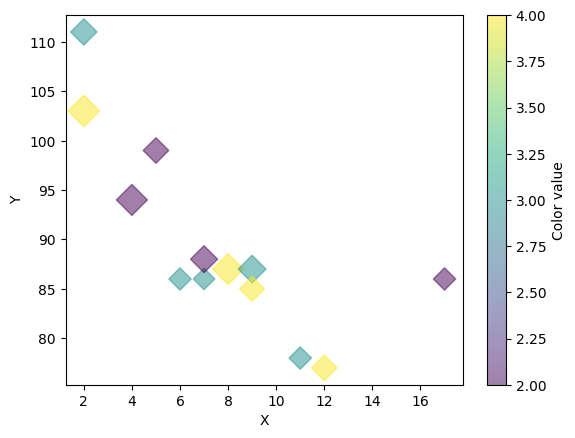

In [13]:
# ---- Customized scatter plot ----
# Here, marker SIZE and COLOR both encode additional variables.
# This is useful for visualizing 3 or 4 variables simultaneously.

x = [5, 7, 8, 7, 2, 17, 2, 9, 4, 11, 12, 9, 6]
y = [99, 86, 87, 88, 111, 86, 103, 87, 94, 78, 77, 85, 86]
size = [170, 120, 250, 190, 180, 130, 260, 200, 250, 130, 170, 160, 130]  # Marker size
color_val = [2, 3, 4, 2, 3, 2, 4, 3, 2, 3, 4, 4, 3]  # Color-mapped values

plt.scatter(x, y,
            s=size,            # Size encodes one variable
            c=color_val,       # Color encodes another variable
            marker='D',        # Diamond markers
            alpha=0.5)         # Semi-transparent

plt.xlabel('X')
plt.ylabel('Y')
plt.colorbar(label='Color value')  # Show the color scale
plt.show()

---
## 12. Customizing Pie Charts <a id='12'></a>

Key customization properties for `plt.pie()`:

| Property | Description |
|---|---|
| `explode` | Pull individual wedges outward (array of offsets) |
| `autopct` | Format string for percentage labels (e.g., `'%1.1f%%'`) |
| `colors` | Custom colors for each slice |
| `shadow` | Add a shadow effect (`True` / `False`) |

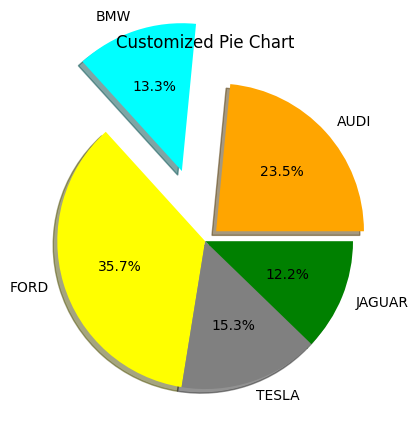

In [14]:
# ---- Customized pie chart ----

cars = ['AUDI', 'BMW', 'FORD', 'TESLA', 'JAGUAR']
data = [23, 13, 35, 15, 12]
explode = [0.1, 0.5, 0, 0, 0]       # Pull AUDI out slightly, BMW out more
colors = ('orange', 'cyan', 'yellow', 'grey', 'green')

plt.pie(data,
        labels=cars,
        explode=explode,
        autopct='%1.1f%%',           # Show percentages with 1 decimal
        colors=colors,
        shadow=True)                 # Add a shadow

plt.title("Customized Pie Chart")
plt.show()

---
# Part III — Figures, Axes, and Subplots

## 13. Figures and Axes — Matplotlib's Core Components <a id='13'></a>

Understanding the difference between **Figures** and **Axes** is the key to mastering Matplotlib.

| Component | What it is | Analogy |
|---|---|---|
| **`Figure`** | The entire canvas/window | The piece of paper |
| **`Axes`** | A single plot area within the figure | A graph drawn on the paper |

A single `Figure` can contain **multiple `Axes`** (subplots). Each `Axes` has its own x-axis, y-axis, title, and data.

### 13a) The `Figure` Object

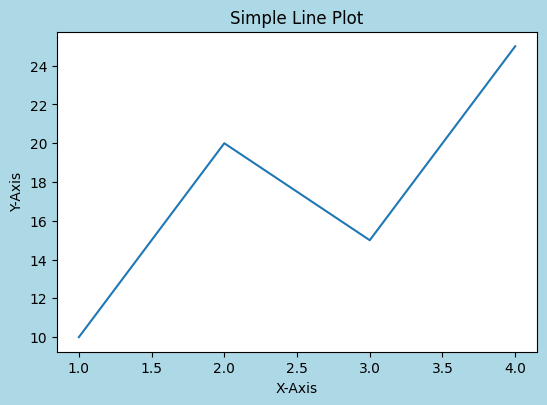

In [15]:
# ---- Creating a Figure and manually adding Axes ----
# fig.add_axes([left, bottom, width, height]) — all as fractions of figure size (0 to 1).

fig = plt.figure(figsize=(6, 4), facecolor='lightblue')  # Canvas size and background

# Add one Axes occupying most of the figure
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])  # left=10%, bottom=10%, width=80%, height=80%

x = [1, 2, 3, 4]
y = [10, 20, 15, 25]
ax.plot(x, y)

ax.set_title("Simple Line Plot")
ax.set_xlabel("X-Axis")
ax.set_ylabel("Y-Axis")
plt.show()

**Key detail:** When using the object-oriented interface (`ax.plot()`, `ax.set_xlabel()`), you call methods on the **Axes** object, not on `plt` directly. This gives you precise control over each subplot.

### 13b) The `Axes` Object — Multiple Lines on One Plot

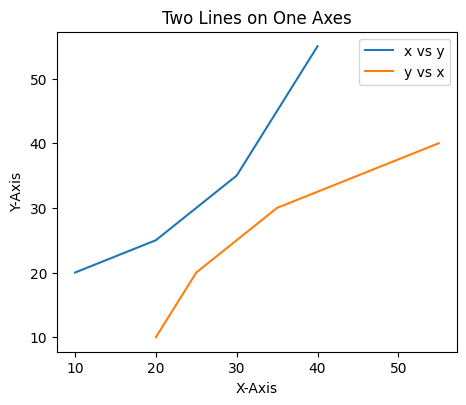

In [16]:
# ---- Plotting multiple lines on a single Axes with a legend ----

x = [10, 20, 30, 40]
y = [20, 25, 35, 55]

fig = plt.figure(figsize=(5, 4))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])

ax.plot(x, y)          # Line 1: x vs y
ax.plot(y, x)          # Line 2: y vs x

ax.set_title("Two Lines on One Axes")
ax.set_xlabel("X-Axis")
ax.set_ylabel("Y-Axis")
ax.legend(labels=('x vs y', 'y vs x'))  # Add a legend
plt.show()

---
## 14. Creating Subplots — `add_axes`, `subplot`, `subplots` <a id='14'></a>

There are several ways to create multiple plots in one figure. Here are the three main approaches, from lowest-level to highest-level.

### Method 1: `fig.add_axes()` — Manual Positioning

You specify the exact position and size of each Axes. Most flexible but most tedious.

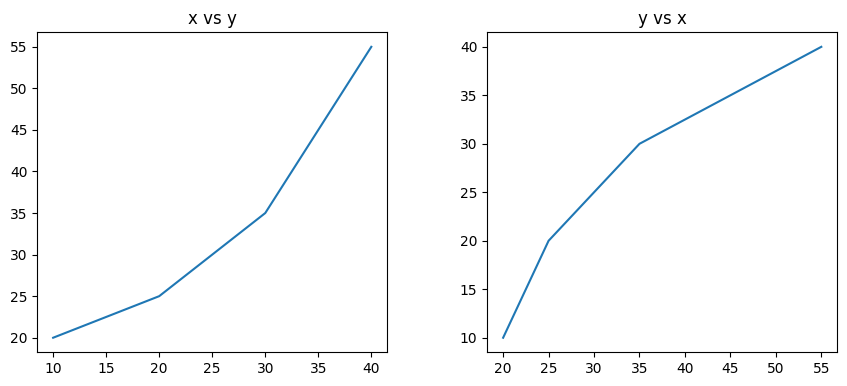

In [17]:
# ---- Two side-by-side plots using add_axes() ----

x = [10, 20, 30, 40]
y = [20, 25, 35, 55]

fig = plt.figure(figsize=(10, 4))

ax1 = fig.add_axes([0.1, 0.1, 0.35, 0.8])   # Left plot
ax2 = fig.add_axes([0.55, 0.1, 0.35, 0.8])   # Right plot

ax1.plot(x, y)
ax1.set_title("x vs y")

ax2.plot(y, x)
ax2.set_title("y vs x")

plt.show()

### Method 2: `plt.subplot()` — Grid Positioning

`plt.subplot(rows, cols, index)` places a plot at a specific grid position. The index starts at 1 (not 0).

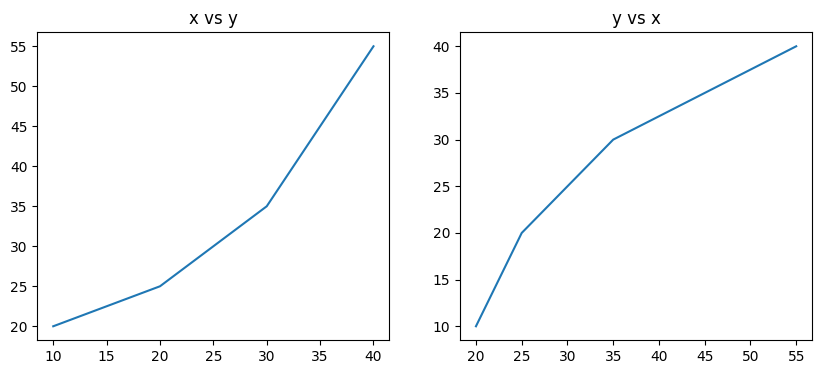

In [18]:
# ---- Two side-by-side plots using subplot() ----
# subplot(121) means: 1 row, 2 columns, position 1
# subplot(122) means: 1 row, 2 columns, position 2

x = [10, 20, 30, 40]
y = [20, 25, 35, 55]

plt.figure(figsize=(10, 4))

plt.subplot(121)         # Left plot
plt.plot(x, y)
plt.title("x vs y")

plt.subplot(122)         # Right plot
plt.plot(y, x)
plt.title("y vs x")

plt.show()

### Method 3: `plt.subplot2grid()` — Grid with Spanning

`subplot2grid` lets you place axes on a grid **and span multiple rows/columns**. Useful for complex layouts.

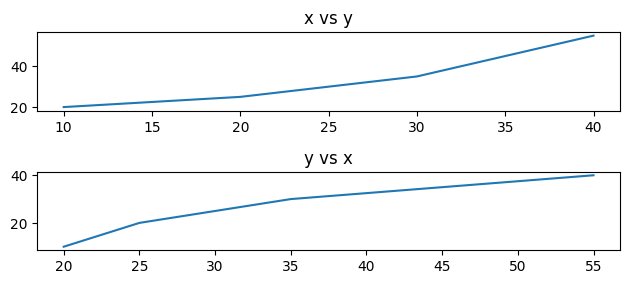

In [19]:
# ---- Two stacked plots using subplot2grid() ----
# Grid is 7 rows × 1 column; each plot spans 2 rows.

x = [10, 20, 30, 40]
y = [20, 25, 35, 55]

axes1 = plt.subplot2grid((7, 1), (0, 0), rowspan=2, colspan=1)
axes2 = plt.subplot2grid((7, 1), (2, 0), rowspan=2, colspan=1)

axes1.plot(x, y)
axes1.set_title("x vs y")

axes2.plot(y, x)
axes2.set_title("y vs x")

plt.tight_layout()
plt.show()

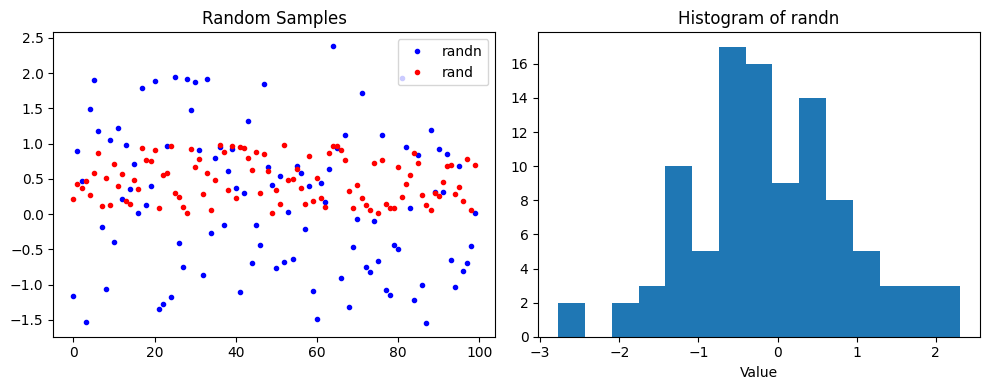

In [20]:
# ---- Quick example: scatter + histogram side by side ----

plt.figure(figsize=(10, 4))

plt.subplot(121)
plt.plot(np.random.randn(100), 'b.', label='randn')   # Standard normal
plt.plot(np.random.rand(100), 'r.', label='rand')      # Uniform [0, 1)
plt.legend()
plt.title("Random Samples")

plt.subplot(122)
plt.hist(np.random.randn(100), bins=15)
plt.xlabel('Value')
plt.title("Histogram of randn")

plt.tight_layout()  # Prevent overlapping labels
plt.show()

---
## 15. Multi-Panel Figures and Saving <a id='15'></a>

### The Recommended Approach: `plt.subplots()`

The **best** way to create multi-panel figures is `plt.subplots(nrows, ncols)`. It returns a `Figure` and an **array of Axes objects** that you can index like a matrix.

This is the approach you'll use for publication-quality figures.

ax is an array of shape: (2, 3)


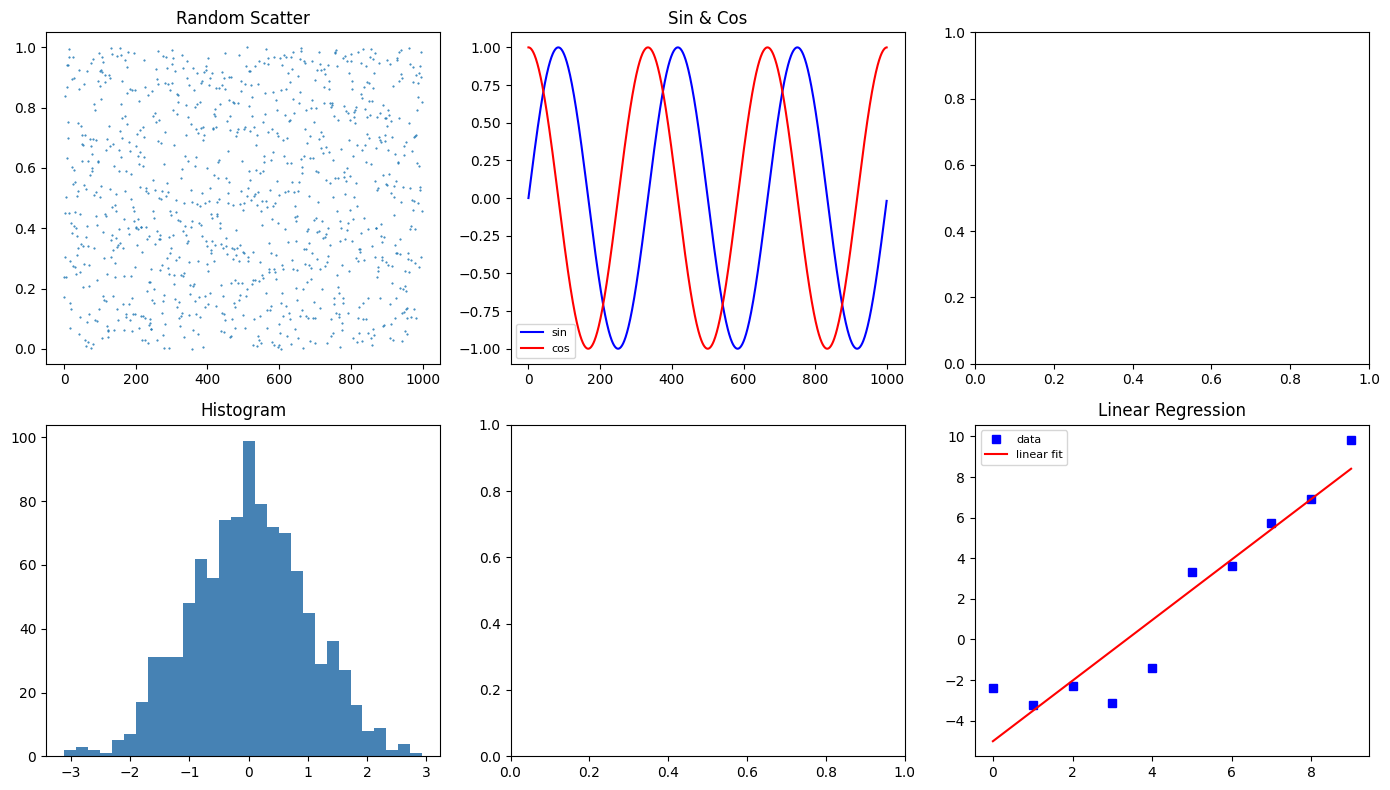

In [21]:
# ---- Multi-panel figure using plt.subplots() ----
# This creates a 2×3 grid of Axes (6 panels total).

fig, ax = plt.subplots(2, 3, figsize=(14, 8))
print(f"ax is an array of shape: {np.shape(ax)}")  # (2, 3)

# ---- Panel [0,0]: Random scatter ----
ax[0, 0].plot(np.random.rand(1000), '.', markersize=1)
ax[0, 0].set_title('Random Scatter')

# ---- Panel [0,1]: Sine and cosine ----
t = np.arange(1000)
ax[0, 1].plot(t, np.sin(2 * np.pi * t * 3 / 1000), 'b-', label='sin')
ax[0, 1].plot(t, np.cos(2 * np.pi * t * 3 / 1000), 'r-', label='cos')
ax[0, 1].legend(fontsize=8)
ax[0, 1].set_title('Sin & Cos')

# ---- Panel [1,0]: Histogram ----
ax[1, 0].hist(np.random.randn(1000), bins=30, color='steelblue')
ax[1, 0].set_title('Histogram')

# ---- Panel [1,2]: Linear fit ----
x = np.arange(10)
y_data = -5 + 1.5 * x + np.random.randn(10) * 2   # Noisy linear data
coef = np.polyfit(x, y_data, 1)                      # Fit a line
y_fit = np.polyval(coef, x)
ax[1, 2].plot(x, y_data, 'bs', label='data')         # Blue squares
ax[1, 2].plot(x, y_fit, 'r-', label='linear fit')    # Red line
ax[1, 2].legend(fontsize=8)
ax[1, 2].set_title('Linear Regression')

plt.tight_layout()  # Adjust spacing so nothing overlaps
plt.show()

# ---- Save the figure to file ----
# fig.savefig("my_figure.pdf")   # Vector format (best for publications)
# fig.savefig("my_figure.png", dpi=300)  # Raster format at 300 DPI

### Saving Figures

| Format | Use case | Code |
|---|---|---|
| **PDF** | Publications, vector graphics | `fig.savefig("fig.pdf")` |
| **PNG** | Presentations, web | `fig.savefig("fig.png", dpi=300)` |
| **SVG** | Editable vector graphics | `fig.savefig("fig.svg")` |

Always use `dpi=300` or higher for raster formats in publications.

---
# Part IV — Practice

## 16. Exercises <a id='16'></a>

---

### Exercise 1: Plot a Synthetic EMG Signal

1. Create a time vector `t` from 0 to 2 seconds at 1000 Hz.
2. Generate a Gaussian activation envelope: `env = np.exp(-0.5 * ((t - 1.0) / 0.2)**2)`
3. Generate synthetic EMG: `emg = env * np.random.randn(len(t)) * 0.5`
4. Plot the raw EMG in gray and the envelope in red on the same axes, with a legend, title, and axis labels.

In [ ]:
# ---- YOUR CODE HERE ----

# t = np.arange(0, 2, 1/1000)
# env = ...
# emg = ...

# plt.figure(figsize=(10, 3))
# plt.plot(t, emg, ...)
# plt.plot(t, env, ...)
# plt.legend(...)
# plt.show()

### Exercise 2: Box Plot Comparing Conditions

Generate reaction time data for 3 conditions:
```python
rng = np.random.default_rng(42)
control = rng.normal(0.350, 0.04, 50)
perturb = rng.normal(0.420, 0.06, 50)
washout = rng.normal(0.370, 0.05, 50)
```

Create a box plot with:
- Custom x-tick labels: `['Control', 'Perturbation', 'Washout']`
- Y-axis label: `'Reaction Time (s)'`
- A title

In [ ]:
# ---- YOUR CODE HERE ----

# rng = np.random.default_rng(42)
# control = ...
# perturb = ...
# washout = ...

# plt.boxplot([control, perturb, washout])
# plt.xticks([1, 2, 3], [...])
# plt.show()

### Exercise 3: Multi-Panel Figure (Challenge)

Create a 2×2 figure using `plt.subplots(2, 2)` that shows:
1. **Top-left:** A reaching trajectory (plot x vs y position as a line)
2. **Top-right:** Velocity profile over time (line plot)
3. **Bottom-left:** Histogram of endpoint errors
4. **Bottom-right:** Bar chart of mean error per condition

Use synthetic data, add titles to each panel, and call `plt.tight_layout()`. Save the figure as a PNG.

In [ ]:
# ---- YOUR CODE HERE ----

# fig, ax = plt.subplots(2, 2, figsize=(10, 8))
#
# # Panel [0,0]: reaching trajectory
# # Panel [0,1]: velocity profile
# # Panel [1,0]: histogram of endpoint errors
# # Panel [1,1]: bar chart of mean error per condition
#
# plt.tight_layout()
# plt.show()
# fig.savefig('exercise3_figure.png', dpi=300)

---
## 17. Summary & Further Reading <a id='17'></a>

### What You Learned

| Plot Type | Function | Best for |
|---|---|---|
| **Line** | `plt.plot()` | Time-series, trends, trajectories |
| **Bar** | `plt.bar()` | Comparing categories |
| **Histogram** | `plt.hist()` | Data distributions |
| **Scatter** | `plt.scatter()` | Relationships between variables |
| **Pie** | `plt.pie()` | Proportions of a whole |
| **Box** | `plt.boxplot()` | Spread, quartiles, outliers |
| **Heatmap** | `plt.imshow()` | Matrices, correlations, spectrograms |

| Concept | What it does |
|---|---|
| **`Figure`** | The entire canvas — controls size, background |
| **`Axes`** | A single plot area — controls data, labels, legend |
| **`plt.subplots(r, c)`** | Create a grid of Axes (recommended approach) |
| **`plt.tight_layout()`** | Auto-fix spacing between subplots |
| **`fig.savefig()`** | Save to PDF, PNG, or SVG |
| **Customization** | `color`, `linewidth`, `marker`, `alpha`, `edgecolor`, etc. |

### Further Reading

- [Matplotlib Official Tutorials](https://matplotlib.org/stable/tutorials/index.html) — the definitive guide
- [Matplotlib Cheatsheets](https://matplotlib.org/cheatsheets/) — quick reference cards (highly recommended)
- [Seaborn](https://seaborn.pydata.org/) — built on Matplotlib, makes statistical plots easier
- [MNE-Python Visualization](https://mne.tools/stable/auto_tutorials/intro/index.html) — uses Matplotlib for EEG/MEG figures
- [Scientific Visualization Book (free)](https://github.com/rougier/scientific-visualization-book) — advanced Matplotlib techniques

### What's Next?

With Matplotlib mastered, you're ready to tackle:
- **Pandas** — tabular data with built-in `.plot()` methods
- **Seaborn** — statistical visualizations (violin plots, pair plots, faceted grids)
- **SciPy** — signal processing (filter, then plot the results!)

---

*Happy plotting, and may your figures be publication-ready on the first try!*